In [ ]:
Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B,source_dataset


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('/home/understressengineer/programming/SRM_PS1/processed_data_v2/merged_data_20Hz.csv')

# df.head()

/tmp/ipykernel_68080/3188378214.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/understressengineer/programming/SRM_PS1/processed_data_v2/merged_data_20Hz.csv')


In [ ]:
# Plot for A Voltage and A Current
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df['Time'], df['A Voltage'], label='A Voltage', color='blue')
plt.plot(df['Time'], df['A Current'], label='A Current', color='red')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('A Voltage and A Current')
plt.legend()

# Plot for B Voltage and B Current
plt.subplot(1, 2, 2)
plt.plot(df['Time'], df['B Voltage'], label='B Voltage', color='green')
plt.plot(df['Time'], df['B Current'], label='B Current', color='orange')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('B Voltage and B Current')
plt.legend()

plt.tight_layout()
plt.show()

TypeError: 'value' must be an instance of str or bytes, not a float

Error in callback <function _draw_all_if_interactive at 0x7f09545be290> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f08e1ffd510> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

/tmp/ipykernel_143795/761359504.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/understressengineer/programming/SRM_PS1/processed_data_v2/merged_data_20Hz.csv')


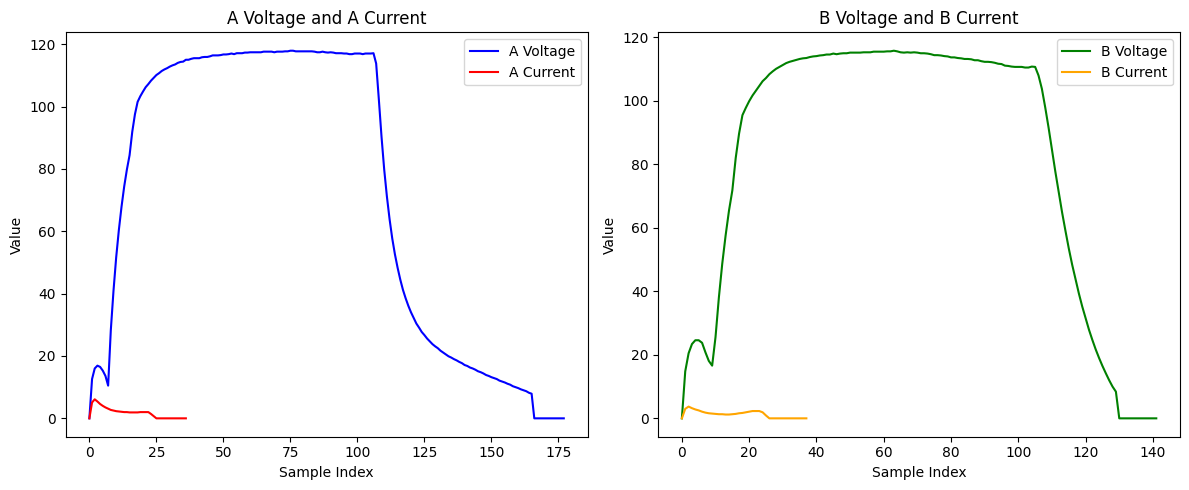

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/home/understressengineer/programming/SRM_PS1/processed_data_v2/merged_data_20Hz.csv')

# Select the first row for plotting
row = df.iloc[0]

# Convert comma-separated strings to lists of floats
def parse_series(series_str):
    return [float(x) for x in str(series_str).split(',') if x.strip() != '']

a_current = parse_series(row['A Current'])
a_voltage = parse_series(row['A Voltage'])
b_current = parse_series(row['B Current'])
b_voltage = parse_series(row['B Voltage'])

# Plot A Voltage and A Current
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(a_voltage, label='A Voltage', color='blue')
plt.plot(a_current, label='A Current', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('A Voltage and A Current')
plt.legend()

# Plot B Voltage and B Current
plt.subplot(1, 2, 2)
plt.plot(b_voltage, label='B Voltage', color='green')
plt.plot(b_current, label='B Current', color='orange')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('B Voltage and B Current')
plt.legend()

plt.tight_layout()
plt.show()

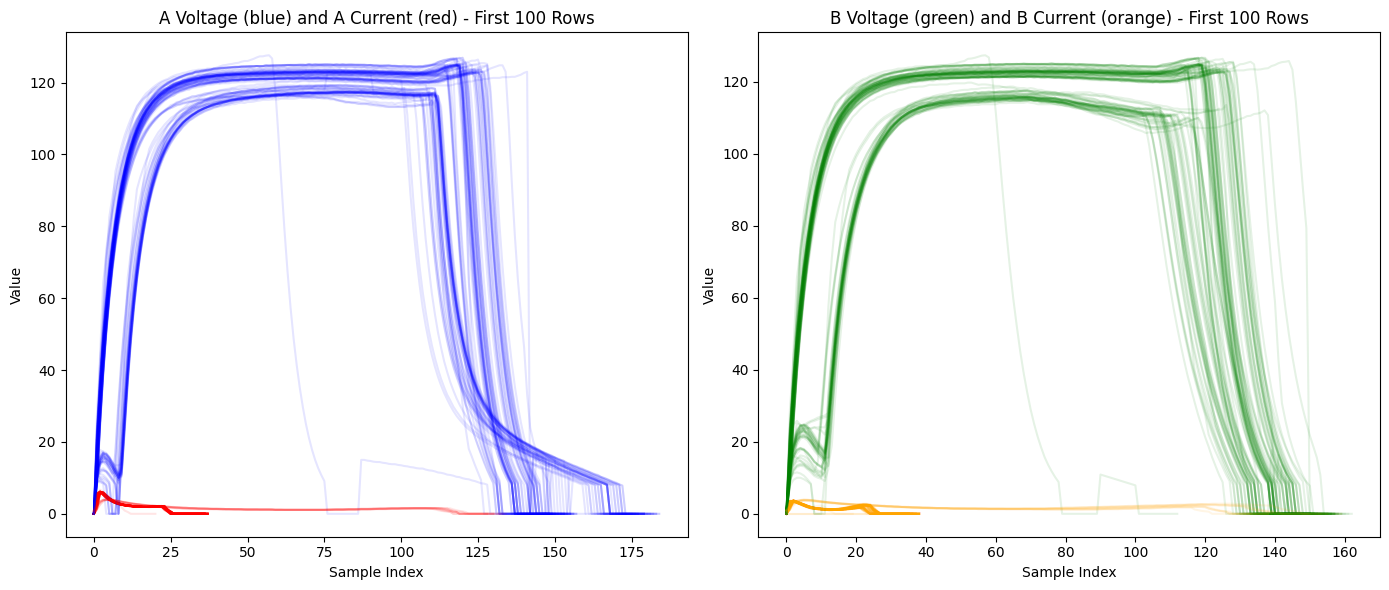

In [2]:
import matplotlib.pyplot as plt

def parse_series(series_str):
    return [float(x) for x in str(series_str).split(',') if x.strip() != '']

plt.figure(figsize=(14, 6))

# Plot A Voltage and A Current for first 100 rows
plt.subplot(1, 2, 1)
for i in range(min(100, len(df))):
    row = df.iloc[i]
    a_voltage = parse_series(row['A Voltage'])
    a_current = parse_series(row['A Current'])
    plt.plot(a_voltage, color='blue', alpha=0.1)
    plt.plot(a_current, color='red', alpha=0.1)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('A Voltage (blue) and A Current (red) - First 100 Rows')

# Plot B Voltage and B Current for first 100 rows
plt.subplot(1, 2, 2)
for i in range(min(100, len(df))):
    row = df.iloc[i]
    b_voltage = parse_series(row['B Voltage'])
    b_current = parse_series(row['B Current'])
    plt.plot(b_voltage, color='green', alpha=0.1)
    plt.plot(b_current, color='orange', alpha=0.1)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('B Voltage (green) and B Current (orange) - First 100 Rows')

plt.tight_layout()
plt.show()

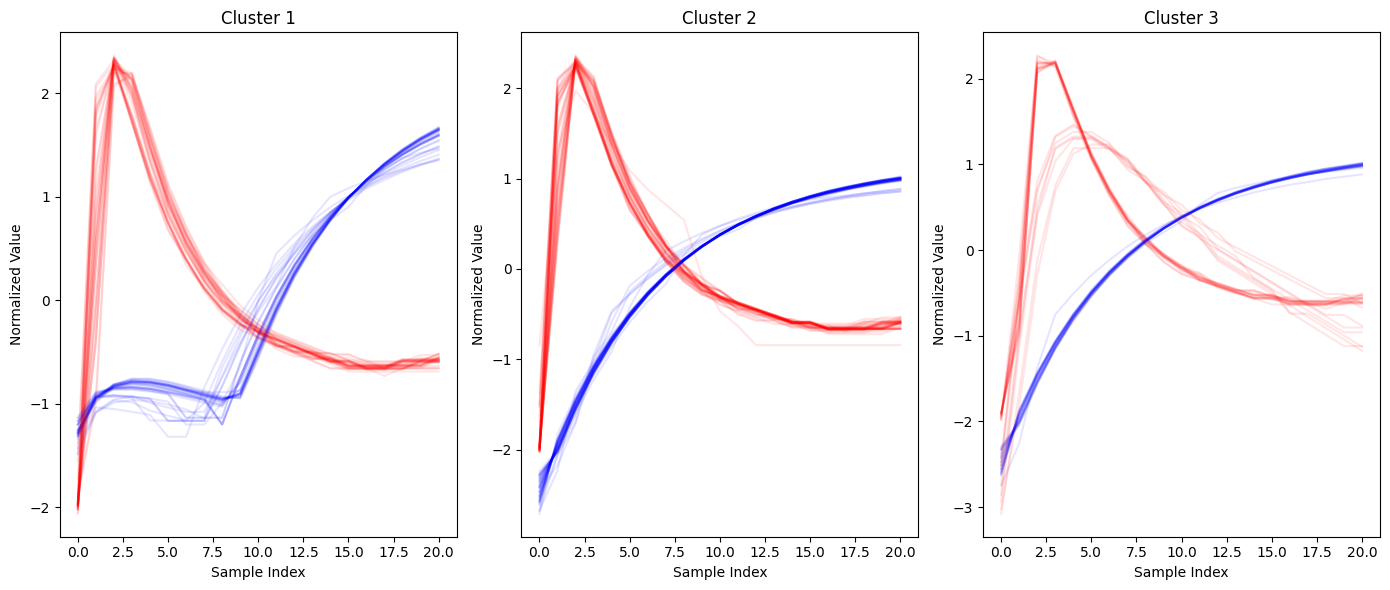

In [4]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def parse_series(series_str):
    return [float(x) for x in str(series_str).split(',') if x.strip() != '']

# Find the minimum length of all series in the first 100 rows
min_len = None
for i in range(min(100, len(df))):
    row = df.iloc[i]
    a_voltage = parse_series(row['A Voltage'])
    a_current = parse_series(row['A Current'])
    length = min(len(a_voltage), len(a_current))
    if min_len is None or length < min_len:
        min_len = length

# Prepare feature matrix with fixed length
features = []
for i in range(min(100, len(df))):
    row = df.iloc[i]
    a_voltage = np.array(parse_series(row['A Voltage']))[:min_len]
    a_current = np.array(parse_series(row['A Current']))[:min_len]
    # Normalize each waveform
    a_voltage = (a_voltage - a_voltage.mean()) / (a_voltage.std() + 1e-8)
    a_current = (a_current - a_current.mean()) / (a_current.std() + 1e-8)
    # Concatenate voltage and current
    features.append(np.concatenate([a_voltage, a_current]))
features = np.array(features)

# Perform KMeans clustering (choose 3 clusters as an example)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(features)

# Plot clustered waveforms
plt.figure(figsize=(14, 6))
for cluster in range(3):
    plt.subplot(1, 3, cluster + 1)
    for i in range(len(features)):
        if labels[i] == cluster:
            plt.plot(features[i][:min_len], color='blue', alpha=0.1)
            plt.plot(features[i][min_len:], color='red', alpha=0.1)
    plt.title(f'Cluster {cluster+1}')
    plt.xlabel('Sample Index')
    plt.ylabel('Normalized Value')
plt.tight_layout()
plt.show()

Number of valid samples for clustering: 13648


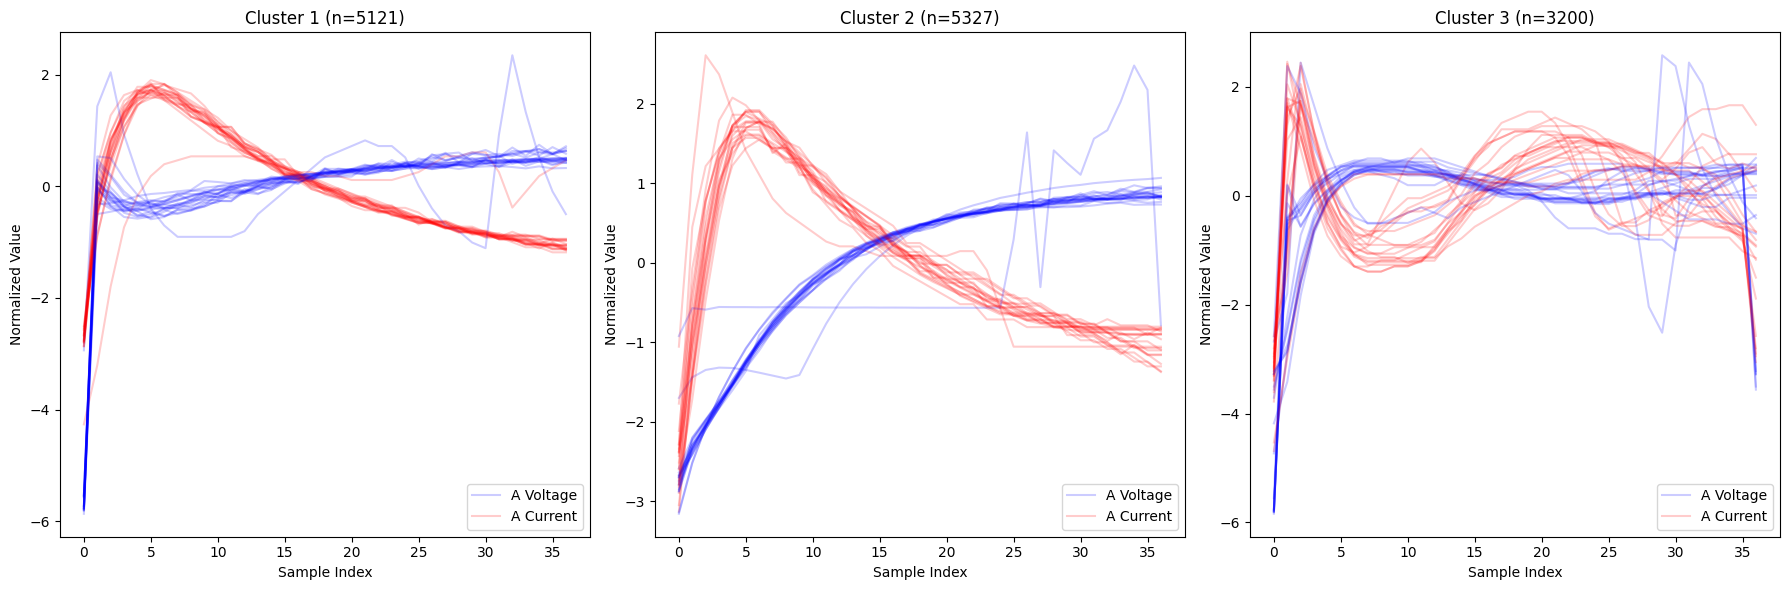

In [10]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def parse_series(series_str):
    return [float(x) for x in str(series_str).split(',') if x.strip() != '']

N = min(20000, len(df))

# Use the length of the first row as the reference length
ref_voltage = parse_series(df.iloc[0]['A Voltage'])
ref_current = parse_series(df.iloc[0]['A Current'])
ref_len = min(len(ref_voltage), len(ref_current))

features = []
valid_indices = []
for i in range(N):
    row = df.iloc[i]
    a_voltage = np.array(parse_series(row['A Voltage']))
    a_current = np.array(parse_series(row['A Current']))
    # Skip rows that are too short
    if len(a_voltage) < ref_len or len(a_current) < ref_len:
        continue
    a_voltage = a_voltage[:ref_len]
    a_current = a_current[:ref_len]
    # Normalize each waveform
    if a_voltage.std() < 1e-8 or a_current.std() < 1e-8:
        continue  # skip flat lines
    a_voltage = (a_voltage - a_voltage.mean()) / (a_voltage.std() + 1e-8)
    a_current = (a_current - a_current.mean()) / (a_current.std() + 1e-8)
    feat = np.concatenate([a_voltage, a_current])
    if np.isnan(feat).any():
        continue
    features.append(feat)
    valid_indices.append(i)
features = np.array(features)

print(f"Number of valid samples for clustering: {len(features)}")

if len(features) == 0:
    print("No valid samples to cluster and plot.")
else:
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features)

    plt.figure(figsize=(18, 6))
    for cluster in range(3):
        plt.subplot(1, 3, cluster + 1)
        idxs = np.where(labels == cluster)[0]
        np.random.shuffle(idxs)
        for i in idxs[:20]:
            plt.plot(features[i][:ref_len], color='blue', alpha=0.2, label='A Voltage' if i == idxs[0] else "")
            plt.plot(features[i][ref_len:], color='red', alpha=0.2, label='A Current' if i == idxs[0] else "")
        plt.title(f'Cluster {cluster+1} (n={len(idxs)})')
        plt.xlabel('Sample Index')
        plt.ylabel('Normalized Value')
        plt.legend()
    plt.tight_layout()
    plt.show()

Number of valid samples for clustering: 1305769


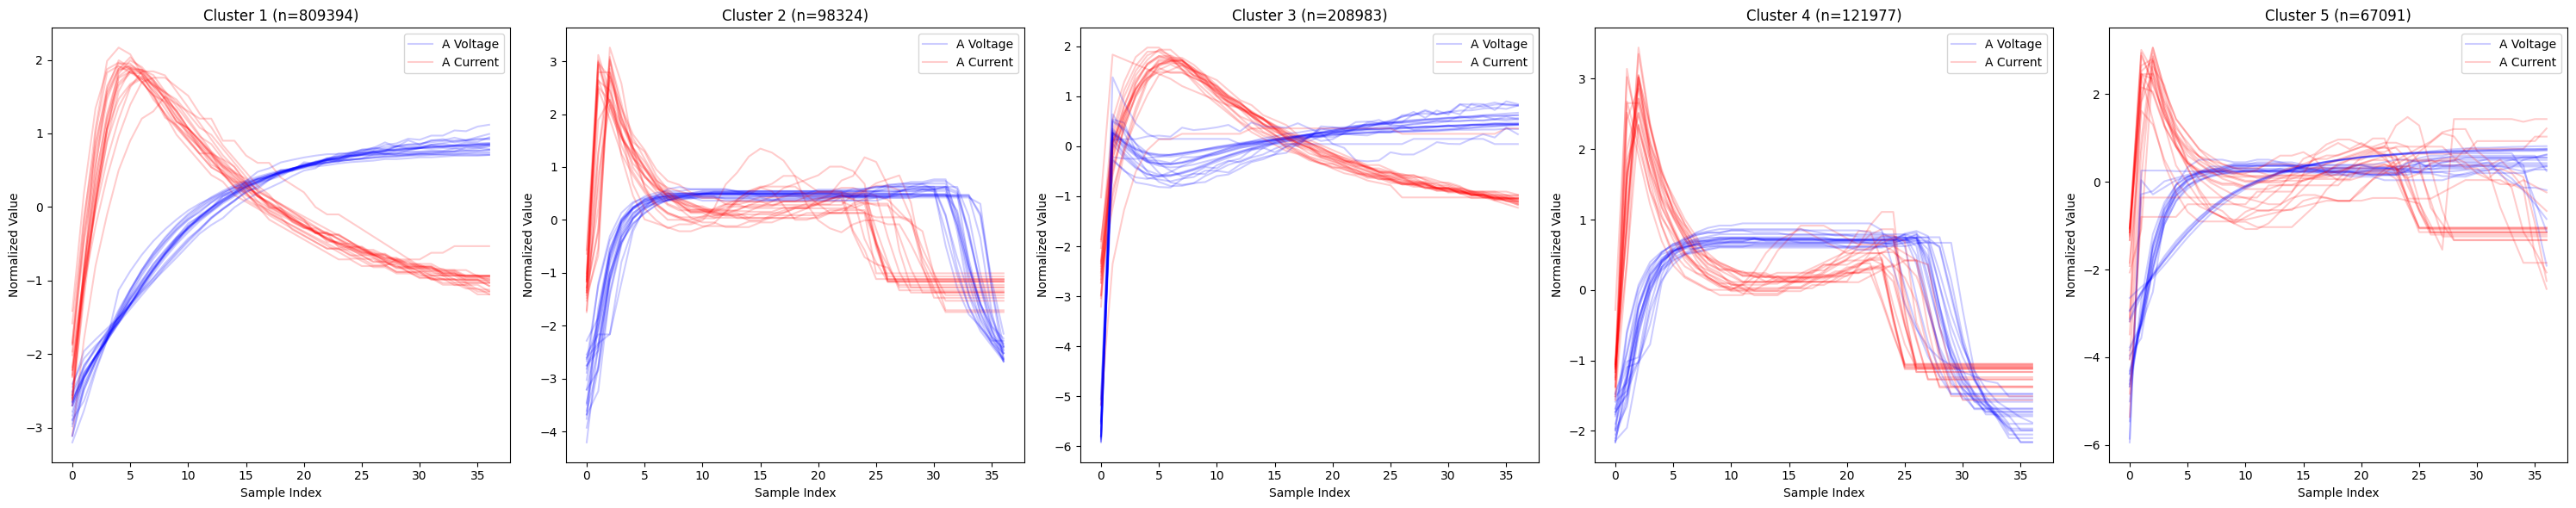

In [12]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def parse_series(series_str):
    values = []
    for x in str(series_str).split(','):
        x = x.strip()
        try:
            values.append(float(x))
        except ValueError:
            continue  # skip non-numeric values
    return values
N = len(df)  # Use all rows

# Use the length of the first row as the reference length
ref_voltage = parse_series(df.iloc[0]['A Voltage'])
ref_current = parse_series(df.iloc[0]['A Current'])
ref_len = min(len(ref_voltage), len(ref_current))

features = []
valid_indices = []
for i in range(N):
    row = df.iloc[i]
    a_voltage = np.array(parse_series(row['A Voltage']))
    a_current = np.array(parse_series(row['A Current']))
    # Skip rows that are too short
    if len(a_voltage) < ref_len or len(a_current) < ref_len:
        continue
    a_voltage = a_voltage[:ref_len]
    a_current = a_current[:ref_len]
    # Normalize each waveform
    if a_voltage.std() < 1e-8 or a_current.std() < 1e-8:
        continue  # skip flat lines
    a_voltage = (a_voltage - a_voltage.mean()) / (a_voltage.std() + 1e-8)
    a_current = (a_current - a_current.mean()) / (a_current.std() + 1e-8)
    feat = np.concatenate([a_voltage, a_current])
    if np.isnan(feat).any():
        continue
    features.append(feat)
    valid_indices.append(i)
features = np.array(features)

print(f"Number of valid samples for clustering: {len(features)}")

if len(features) == 0:
    print("No valid samples to cluster and plot.")
else:
    n_clusters = 5  # Change this to any number of clusters you want
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features)

    plt.figure(figsize=(6 * n_clusters, 6))
    for cluster in range(n_clusters):
        plt.subplot(1, n_clusters, cluster + 1)
        idxs = np.where(labels == cluster)[0]
        np.random.shuffle(idxs)
        for i in idxs[:20]:
            plt.plot(features[i][:ref_len], color='blue', alpha=0.2, label='A Voltage' if i == idxs[0] else "")
            plt.plot(features[i][ref_len:], color='red', alpha=0.2, label='A Current' if i == idxs[0] else "")
        plt.title(f'Cluster {cluster+1} (n={len(idxs)})')
        plt.xlabel('Sample Index')
        plt.ylabel('Normalized Value')
        plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Test commit